# A Matrix Is a Function That Moves Space

**This notebook teaches linear transformations from scratch, it assumes only that you can multiply a matrix by a vector.**

So far a matrix has been a grid of numbers you multiply by. This notebook shows the other thing it is: a **function** that takes a point and moves it somewhere else. The payoff is a trick that makes every transformation matrix readable at a glance, feed the matrix the two unit vectors, and its columns tell you exactly where they land.

## Learning objectives

- Read $A\mathbf{x}$ as a linear combination of $A$'s columns **and** as the image of $\mathbf{x}$.
- Show that $A\hat{\imath}$ and $A\hat{\jmath}$ are the first and second **columns** of $A$.
- Build a transformation matrix by deciding where $\hat{\imath}$ and $\hat{\jmath}$ should go.

## Background

A vector is written as a **column**, e.g. $\mathbf{x} = \begin{bmatrix} 5 \\ 6 \end{bmatrix}$. Multiplying a matrix by a vector gives another vector, and there are two ways to read the result:

$$A\mathbf{x} \;=\; \begin{bmatrix}a & b\\ c & d\end{bmatrix}\begin{bmatrix}x_1\\x_2\end{bmatrix} \;=\; \underbrace{x_1\begin{bmatrix}a\\c\end{bmatrix} + x_2\begin{bmatrix}b\\d\end{bmatrix}}_{\text{a combination of } A\text{'s columns}} \;=\; \underbrace{\begin{bmatrix}ax_1 + bx_2\\ cx_1 + dx_2\end{bmatrix}}_{\text{a new point}}$$

The **unit vectors** are $\hat{\imath} = \begin{bmatrix}1\\0\end{bmatrix}$ (one step right) and $\hat{\jmath} = \begin{bmatrix}0\\1\end{bmatrix}$ (one step up). A **linear transformation** is a rule that moves every point of the plane using one fixed matrix.

## This notebook covers

1. One point through $A$, both readings of the same product.
2. Where $\hat{\imath}$ and $\hat{\jmath}$ land: reading the columns off.
3. Every point at once: a whole shape moved by $A$.
4. Going backwards: choose the images, write down the matrix.

**Prerequisites:** `U2-3_Matrices-2_MultiplicationAndPowers`

**Dataset:** none, matrices and points are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)
# plotting helper: draw one vector as an arrow starting at `tail`
# (zorder keeps arrows on top of the axis spines, which are the same white)
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles='xy', scale_units='xy',
              scale=1, color=color, label=label, alpha=alpha, width=0.011, zorder=5)
# an "F" outline: deliberately asymmetric, so a reflection is impossible to miss
F = np.array([[0.0, 0.0], [0.0, 1.0], [0.6, 1.0], [0.6, 0.8], [0.2, 0.8],
              [0.2, 0.6], [0.5, 0.6], [0.5, 0.4], [0.2, 0.4], [0.2, 0.0],
              [0.0, 0.0]]).T          # 2 x n: each COLUMN is a point, so A @ F transforms them all

def draw_shape(ax, pts, color, label=None, alpha=1.0, lw=2):
    ax.plot(pts[0], pts[1], color=color, label=label, alpha=alpha, lw=lw)
    ax.fill(pts[0], pts[1], color=color, alpha=0.15 * alpha)

## 1. One point, two readings

Take $A = \begin{bmatrix}2 & 1\\ 0 & 3\end{bmatrix}$ and the point $\mathbf{x} = \begin{bmatrix}1\\1\end{bmatrix}$.

**Reading 1, a combination of columns.** Use the entries of $\mathbf{x}$ as the amounts of each column:

$$1\begin{bmatrix}2\\0\end{bmatrix} + 1\begin{bmatrix}1\\3\end{bmatrix} = \begin{bmatrix}3\\3\end{bmatrix}$$

**Reading 2, a point that moved.** The arrow that pointed to $(1,1)$ now points to $(3,3)$.

Same arithmetic, two stories. The second is the one this section is about: $A$ is a **machine that moves points**.

In [2]:
A = np.array([[2, 1],
              [0, 3]])
x = np.array([1, 1])

helpers.show(A, name="A")
helpers.show(x, name=r"\mathbf{x}")
helpers.show(A @ x, name=r"A\mathbf{x}")

# reading 1: the same answer, built from the columns of A
helpers.show(x[0] * A[:, 0] + x[1] * A[:, 1], label="as a combination of columns")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

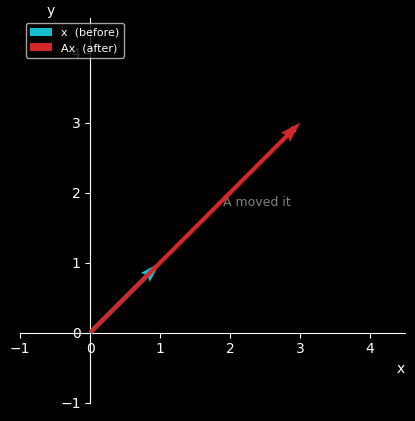

In [3]:
# --- graphics: the point before and after ---
fig, ax = plt.subplots(figsize=(6, 5))
arrow(ax, (0, 0), x, "tab:cyan", "x  (before)")
arrow(ax, (0, 0), A @ x, "tab:red", "Ax  (after)")
ax.annotate("", xy=tuple(A @ x), xytext=tuple(x),
            arrowprops=dict(arrowstyle="->", color="gray", ls=":"))
ax.text(1.9, 1.8, "A moved it", color="gray", fontsize=9)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-1, 4.5); ax.set_ylim(-1, 4.5); ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
plt.show()

## 2. Where do $\hat{\imath}$ and $\hat{\jmath}$ land?

Here is the trick that makes every transformation matrix readable. Feed $A$ the unit vector $\hat{\imath} = \begin{bmatrix}1\\0\end{bmatrix}$:

$$A\hat{\imath} = 1\begin{bmatrix}a\\c\end{bmatrix} + 0\begin{bmatrix}b\\d\end{bmatrix} = \begin{bmatrix}a\\c\end{bmatrix}$$

That is exactly the **first column** of $A$. Likewise $A\hat{\jmath}$ is the **second column**. So:

> **The columns of $A$ are the places $\hat{\imath}$ and $\hat{\jmath}$ get sent.**

This is worth memorizing, because it turns reading a matrix into reading a picture. Given any matrix, you now know where the two unit vectors go, and since every other vector is built from those two, you know where *everything* goes.

In [4]:
i_hat = np.array([1, 0])
j_hat = np.array([0, 1])

helpers.show(A @ i_hat, label=r"A\hat{\imath} = first column of A")
helpers.show(A @ j_hat, label=r"A\hat{\jmath} = second column of A")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

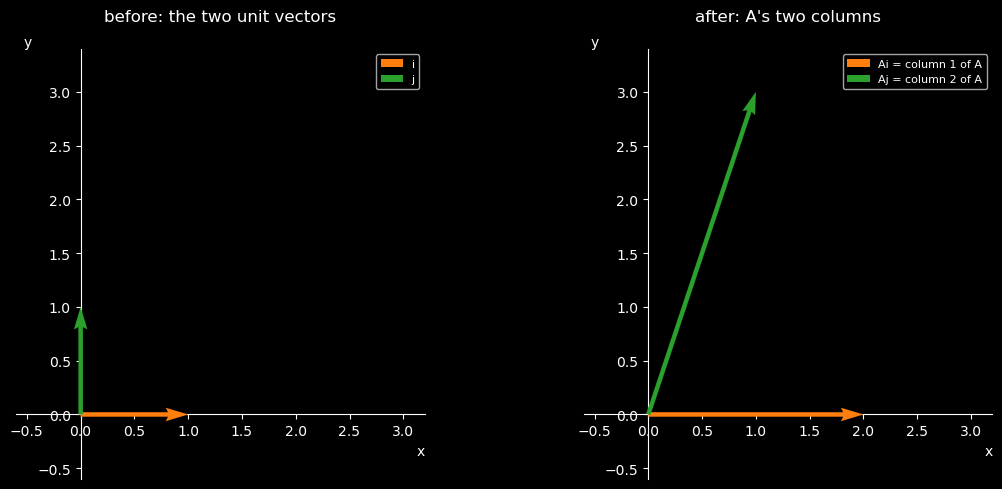

In [5]:
# --- graphics: the unit vectors and where they land ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
arrow(ax, (0, 0), i_hat, "tab:orange", "i")
arrow(ax, (0, 0), j_hat, "tab:green", "j")
ax.set_title("before: the two unit vectors", pad=20)

ax = axes[1]
arrow(ax, (0, 0), A @ i_hat, "tab:orange", "Ai = column 1 of A")
arrow(ax, (0, 0), A @ j_hat, "tab:green", "Aj = column 2 of A")
ax.set_title("after: A's two columns", pad=20)

for ax in axes:
    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.set_ylabel("y", loc="top", rotation=0)
    ax.set_xlim(-0.6, 3.2); ax.set_ylim(-0.6, 3.4); ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Every point at once

A transformation doesn't move one point, it moves **all of them**, with the same matrix. To see that, we take a whole shape (an "F", chosen because it is lopsided enough that you can always tell how it has been turned or flipped) and multiply every one of its corner points by $A$.

Storing the corners as the **columns** of a $2 \times n$ array lets `A @ F` transform all of them in a single product.

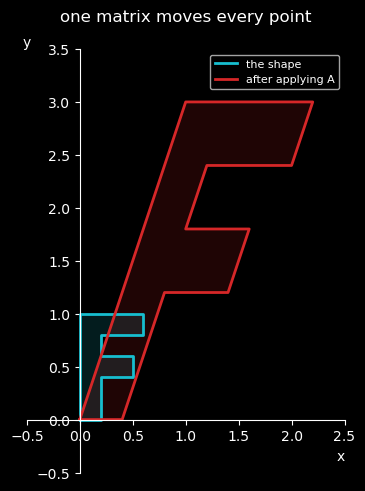

In [6]:
fig, ax = plt.subplots(figsize=(6, 5.5))
draw_shape(ax, F, "tab:cyan", "the shape")
draw_shape(ax, A @ F, "tab:red", "after applying A")

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 3.5); ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("one matrix moves every point", pad=20)
plt.show()

## 4. Going backwards: build the matrix you want

Because the columns *are* the images of $\hat{\imath}$ and $\hat{\jmath}$, you can design a transformation by deciding where those two arrows should end up and then simply writing them down as columns.

Say we want $\hat{\imath} \mapsto \begin{bmatrix}0\\1\end{bmatrix}$ and $\hat{\jmath} \mapsto \begin{bmatrix}-1\\0\end{bmatrix}$, that is, both arrows swung a quarter turn counterclockwise. Stack them as columns:

$$A = \begin{bmatrix}0 & -1\\ 1 & 0\end{bmatrix}$$

and we have built a 90° rotation without looking anything up. The next notebook does this for every named transformation.

<IPython.core.display.Math object>

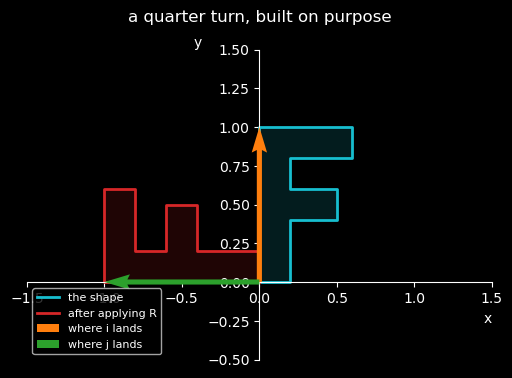

In [7]:
# decide where the two unit vectors should land, then stack them as columns
new_i = np.array([0, 1])     # i goes up
new_j = np.array([-1, 0])    # j goes left

R = np.column_stack([new_i, new_j])
helpers.show(R, name="R")

fig, ax = plt.subplots(figsize=(6, 5.5))
draw_shape(ax, F, "tab:cyan", "the shape")
draw_shape(ax, R @ F, "tab:red", "after applying R")
arrow(ax, (0, 0), new_i, "tab:orange", "where i lands")
arrow(ax, (0, 0), new_j, "tab:green", "where j lands")

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-0.5, 1.5); ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=8)
ax.set_title("a quarter turn, built on purpose", pad=20)
plt.show()

## 5. Summary

- $A\mathbf{x}$ reads two ways: a **combination of $A$'s columns**, and the **image of the point** $\mathbf{x}$. This section uses the second reading.
- **The columns of $A$ are where $\hat{\imath}$ and $\hat{\jmath}$ land.** Read a matrix, and you know what the transformation does.
- One matrix moves *every* point the same way, apply it to a whole shape at once.
- To design a transformation, decide the two images and stack them as columns.

Next: the named transformations, rotation, reflection, scaling, shear, projection, each read straight off its columns (`U2-4_Transformations-2_NamedTransforms`).